# STA4365: Group 10 Final Project
## Contributers: Simon Hernandez, Erick Rodriquez, Franco Vidal, and Andres Machado

In [ ]:
import numpy as np
import pandas as pd
from pandas.plotting import autocorrelation_plot
import matplotlib.pyplot as plt
# from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
import torch

# EDA

## Importing Data

In [ ]:
df = pd.read_csv('train.csv')
print(df.info()) # checking types
df.head()

In [ ]:
# Count of the nan types in each column
nan_count = df.isna().sum()
nan_count

## Visualizations

In [ ]:
cols = ['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size', 'imbalance_buy_sell_flag', 'reference_price', 'matched_size', 'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price', 'ask_size', 'wap', 'target', 'time_id']
x = df[cols]

In [ ]:
sorted(x["stock_id"].unique())

In [ ]:
stock_id = 1
subset = df[df["stock_id"] == stock_id]
data = subset.sort_values(['date_id', 'seconds_in_bucket'])
plot_acf(data['target'], lags=60, title=f'ACF for: {stock_id}')
plt.show()

In [ ]:
stock_ids = df['stock_id'].unique()

for stock_id in stock_ids:
    subset = df[df["stock_id"] == stock_id]
    data = subset.sort_values(['date_id', 'seconds_in_bucket'])
    plot_acf(data['target'], lags=60, title=f'ACF for: {stock_id}')
    #plt.show()

In [ ]:
p_vals = []
for i in range(200):
    subsetComp = df[df["stock_id"] == i]
    subsetComp = subsetComp.dropna(subset=['reference_price'])
    print("hiii :3 : ", i, "|", subsetComp['reference_price'].isna().sum())
    p_vals.append((adfuller(subsetComp["reference_price"]))[1])

print(p_vals)

In [65]:
df.tail(20)

,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
5237960,180,480,540,563043.09,-1,0.998141,6.717567e+06,0.996492,0.996767,0.997866,29322.32,0.998141,13757.70,0.998054,15.909672,26454,480_540_180
5237961,181,480,540,498430.75,1,1.001248,1.384217e+07,1.001527,1.001304,1.001081,1256.85,1.001304,59803.47,1.001085,-2.139807,26454,480_540_181
5237962,182,480,540,2685032.08,1,0.999491,3.848839e+07,1.000210,1.000210,0.999311,210094.58,0.999491,134544.78,0.999421,3.750324,26454,480_540_182
5237963,183,480,540,571821.88,-1,0.996694,9.752797e+07,0.996468,0.996468,0.996694,19896.75,0.996807,83487.36,0.996716,1.029968,26454,480_540_183
5237964,184,480,540,283509.38,1,0.996650,1.590741e+07,0.998372,0.997156,0.996447,63619.51,0.996650,75336.10,0.996540,-4.770160,26454,480_540_184
5237965,185,480,540,3018493.53,-1,1.000057,2.723894e+07,0.997937,0.998915,1.000029,29442.40,1.000301,225663.69,1.000061,-7.209778,26454,480_540_185
5237966,186,480,540,2106025.88,-1,0.999780,1.988346e+07,0.998713,0.998713,0.999780,174758.40,0.999933,516941.19,0.999819,-9.809732,26454,480_540_186
5237967,187,480,540,3791745.66,1,0.999641,3.380628e+07,1.000641,1.000564,0.999564,24031.50,0.999641,73788.88,0.999583,0.289679,26454,480_540_187
5237968,188,480,540,18930.38,-1,0.999741,6.465049e+06,0.999741,0.999741,0.999741,117186.86,1.000297,217260.00,0.999936,-0.699758,26454,480_540_188
5237969,189,480,540,956757.96,1,1.000715,3.710938e+07,1.001167,1.001054,1.000602,788361.12,1.000715,49599.20,1.000708,6.959438,26454,480_540_189


In [ ]:
# Plots 7 stocks performance on a given day within the last 10 minutes of market action
for i in range(0, 8):
    company_i = x[(x['stock_id'] == i) & (x['date_id'] == 0)]
    plt.title(f'Stock {i}\'s movement against the seconds in the bucket on a given day')
    plt.xlabel(f'Seconds in the bucket')
    plt.ylabel(f'Stock movement for Stock {i}')
    plt.plot(company_i['seconds_in_bucket'], company_i['target'])
    plt.show()

In [68]:
for stock in stock_ids:
    subset = df[df["stock_id"] == stock_id]
    num_far_nans = subset['far_price'].isna().sum()
    print(num_far_nans)

5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631
5631


In [84]:
stock_id = 1
subset = df[df["stock_id"] == stock_id]
nan_elements = []
for index, row in df.iterrows():
    if np.isnan(row['far_price']): nan_elements.append(row['time_id'])
nan_elements

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


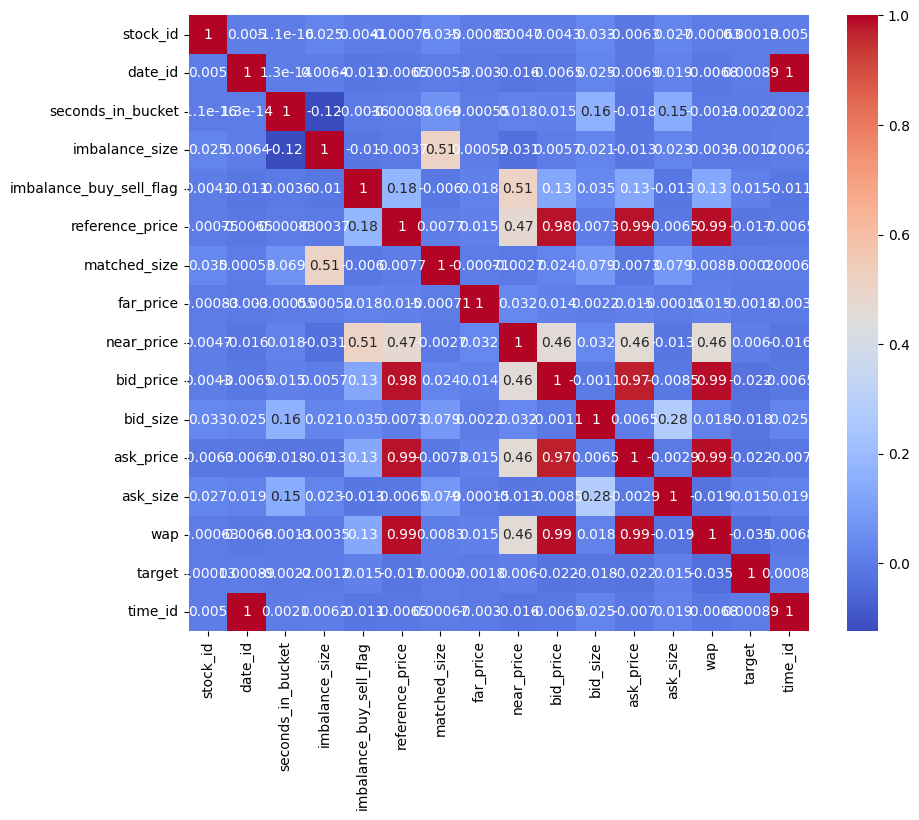

In [ ]:
import seaborn as sns
corr_matrix = x.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()